# Notebook 4 - Lasso and stochastic gradient descent

Project 1, parts g and h.

Anne Kristin Furu, FYS-STK4155, fall 2026.

**LLM note.** This notebook was produced with Claude (Opus 4.8, claude.ai, Sept-Oct 2026) at code level 4: the analysis and figures were generated from the author's design and weekly-exercise solutions, and the author ran, checked and verified the results. See Appendix A of the report.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import grad
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from Errors import mse
from LASSO import lasso_ista, lasso_subgradient, soft_threshold
from optimisers import sgd, make_batches, step_length
from helper import ols_ridge_gradient, hessian_eigs
from OLS import ols_svd
from Ridge import ridge_closed_form
from sklearn.linear_model import Lasso as SKLasso
np.set_printoptions(precision=4, suppress=True)

x, y = make_data(n=100, noise=0.1, seed=SEED)

## Part g: Lasso via gradient descent

Lasso adds the penalty $\lambda\|\theta\|_1$. It has no closed form, so we solve it with gradient descent. The $\ell_1$ penalty is not differentiable at $\theta_j = 0$, which is what we handle first.

### The subgradient at zero

At $\theta_j = 0$ the absolute value has no single derivative; its subdifferential is the whole interval $[-1, 1]$. We ask `jax.grad` for the derivative of $|\theta|$ at zero.

In [2]:
gabs = grad(lambda t: jnp.abs(t))
print('d|t|/dt at 0 =', float(gabs(0.0)))
print('d|t|/dt at 2 =', float(gabs(2.0)))
print('d|t|/dt at -2 =', float(gabs(-2.0)))

d|t|/dt at 0 = 1.0
d|t|/dt at 2 = 1.0
d|t|/dt at -2 = -1.0


JAX returns 1 at zero. That is a valid subgradient, since 1 lies in the subdifferential $[-1, 1]$, but it is only one choice. Subgradient descent therefore takes a fixed nonzero step at the kink and never sets a coefficient exactly to zero. The cleaner tool is proximal gradient descent, ISTA: take a plain gradient step on the smooth data term, then apply the soft thresholding operator $S_t(z) = \mathrm{sign}(z)\max(|z|-t,0)$, which is the proximal operator of the $\ell_1$ penalty and does drive coefficients to zero.

### Verification against scikit-learn

On degree-10 Runge we set the step from the Hessian, $\gamma = 1/L$ with $L$ the largest eigenvalue, and compare our ISTA solution with scikit-learn Lasso. Note scikit-learn minimises with a $1/(2n)$ data term, so its alpha is our $\lambda/2$.

In [3]:
d = 10
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
L = hessian_eigs(Xtr).max()
gamma = 1.0 / L
print(f'L = {L:.3f}, gamma = 1/L = {gamma:.4f}')

for lam in (0.01, 0.05):
    th = lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=200000, tol=1e-12)
    sk = SKLasso(alpha=lam / 2, fit_intercept=False, max_iter=500000, tol=1e-12).fit(Xtr, ytr)
    diff = np.max(np.abs(th - sk.coef_))
    nz = int((np.abs(th) > 1e-8).sum())
    print(f'lambda={lam}: max|ISTA - sklearn| = {diff:.2e}, nonzero {nz}/{d}')

L = 12.787, gamma = 1/L = 0.0782
lambda=0.01: max|ISTA - sklearn| = 1.11e-10, nonzero 3/10
lambda=0.05: max|ISTA - sklearn| = 2.01e-11, nonzero 2/10


Our own Lasso matches scikit-learn to about 1e-10, and both leave only a few nonzero coefficients. The implementation is verified.

### Sparsity: Lasso versus Ridge

The point of Lasso is that it sets coefficients exactly to zero, which Ridge never does. We count the nonzero coefficients as a function of the penalty for both methods.

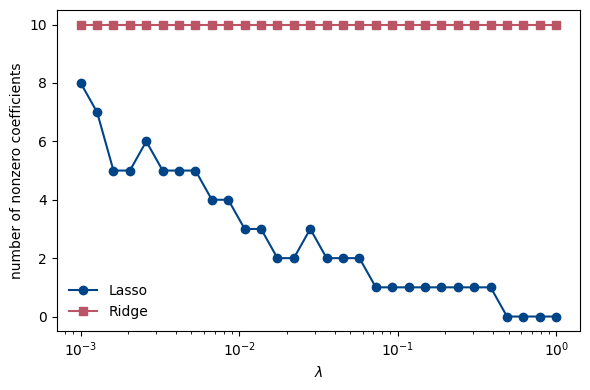

In [4]:
lams = np.logspace(-3, 0, 30)
nz_lasso, nz_ridge = [], []
for lam in lams:
    tl = lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=20000, tol=1e-10)
    tr = ridge_closed_form(Xtr, ytr, lam)
    nz_lasso.append(int((np.abs(tl) > 1e-8).sum()))
    nz_ridge.append(int((np.abs(tr) > 1e-8).sum()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lams, nz_lasso, 'o-', color=BLUE, label='Lasso')
ax.plot(lams, nz_ridge, 's-', color=RED, label='Ridge')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('number of nonzero coefficients')
ax.legend(frameon=False)
fig.tight_layout()
savefig('g_sparsity', fig)
plt.show()

Lasso removes coefficients one by one as the penalty grows, ending with a sparse model. Ridge keeps all ten, only shrinking them. This is the difference between the $\ell_1$ and $\ell_2$ penalties.

best lambda 0.001, test MSE 0.0207


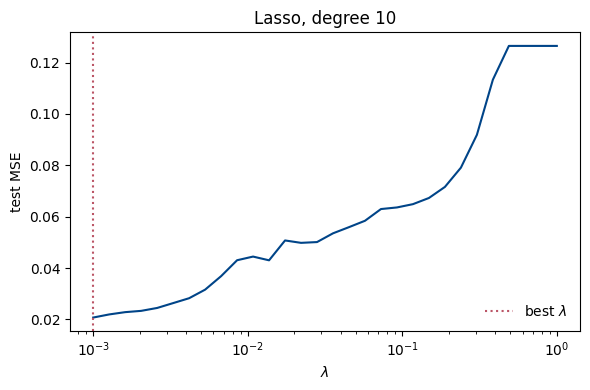

In [5]:
# Test MSE versus lambda for Lasso
mses = [mse(yte, Xte @ lasso_ista(Xtr, ytr, lam, gamma=gamma, num_iters=20000, tol=1e-10)) for lam in lams]
best = int(np.argmin(mses))
print(f'best lambda {lams[best]:.3g}, test MSE {mses[best]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lams, mses, '-', color=BLUE)
ax.axvline(lams[best], ls=':', color=RED, label='best $\\lambda$')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('test MSE')
ax.set_title(f'Lasso, degree {d}')
ax.legend(frameon=False)
fig.tight_layout()
savefig('g_lasso_mse', fig)
plt.show()

The test error is lowest at a small penalty and rises as too many coefficients are removed. Model selection by cross-validation is done in part i.

## Part h: stochastic gradient descent

We replace the full gradient by a minibatch gradient inside an epoch loop. Every optimiser from part f works with minibatches unchanged. We study the minibatch on the well-conditioned degree-2 Runge problem, where full-batch gradient descent converges cleanly, so the effect of the noise is easy to see. The high-degree, ill-conditioned case is where the adaptive methods of part f and the final model selection of part i take over.

### Minibatch gradient noise

At a fixed point we compute the gradient on many random minibatches and compare their spread with the full gradient. The spread falls as $1/\sqrt{M}$.

In [6]:
d = 2
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
n_tr = Xtr.shape[0]
theta_fixed = np.zeros(Xtr.shape[1])
g_full = ols_ridge_gradient(theta_fixed, Xtr, ytr, 0.0)
rng = np.random.default_rng(2026)
print('full gradient norm:', round(np.linalg.norm(g_full), 4))
prev = None
for M in (1, 5, 25):
    gs = np.array([ols_ridge_gradient(theta_fixed, Xtr[b], ytr[b], 0.0)
                   for _ in range(40) for b in make_batches(n_tr, M, rng)])
    spread = np.std(gs, axis=0).mean()
    ratio = '' if prev is None else f'  (drops x{prev / spread:.2f}, expect sqrt(5)=2.24)'
    print(f'M={M:2d}: spread {spread:.3f}{ratio}')
    prev = spread

full gradient norm: 0.437
M= 1: spread 0.518
M= 5: spread 0.226  (drops x2.29, expect sqrt(5)=2.24)
M=25: spread 0.137  (drops x1.65, expect sqrt(5)=2.24)


The spread falls by about a factor 2.2 each time M is multiplied by 5, matching $1/\sqrt{M}$. A small batch is noisy but cheap per step.

### SGD versus full batch, and the schedule

We run plain SGD with M = 5 at two constant learning rates and with the schedule $\gamma_t = t_0/(t+t_1)$, and compare with full-batch gradient descent. Distance to the closed-form solution against the number of single-point gradient evaluations.

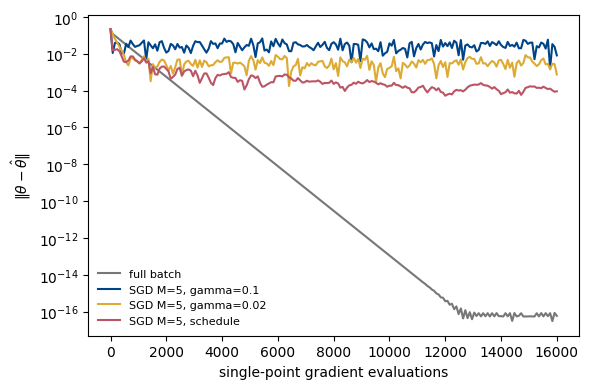

In [7]:
gb = lambda th, Xb, yb: ols_ridge_gradient(th, Xb, yb, 0.0)
n_epochs = 200
evals = np.arange(n_epochs + 1) * n_tr

runs = [
    (dict(batch_size=n_tr, gamma=0.9 * 2 / hessian_eigs(Xtr).max()), GREY, 'full batch'),
    (dict(batch_size=5, gamma=0.1), BLUE, 'SGD M=5, gamma=0.1'),
    (dict(batch_size=5, gamma=0.02), YELLOW, 'SGD M=5, gamma=0.02'),
    (dict(batch_size=5, schedule=(5.0, 50.0)), RED, 'SGD M=5, schedule'),
]
fig, ax = plt.subplots(figsize=(6, 4))
for kw, col, lab in runs:
    hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method='plain', n_epochs=n_epochs, **kw)
    ax.semilogy(evals, np.linalg.norm(hist - theta_hat, axis=1), color=col, label=lab)
ax.set_xlabel('single-point gradient evaluations')
ax.set_ylabel(r'$\|\theta - \hat\theta\|$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
savefig('h_sgd_vs_full', fig)
plt.show()

Full-batch gradient descent converges geometrically. SGD at a constant learning rate does not converge; it settles on a plateau whose height scales with the learning rate, because the iterate is a random walk in a cloud of radius set by gamma. The decaying schedule shrinks that cloud and keeps descending.

In [8]:
# Minibatch size study at degree 6, gamma = 0.1, 200 epochs
print('final distance to closed form after 200 epochs, gamma=0.1:')
for M in (1, 5, 20, 100):
    with np.errstate(over='ignore', invalid='ignore'):
        hist = sgd(gb, np.zeros(Xtr.shape[1]), Xtr, ytr, method='plain', n_epochs=200, batch_size=M, gamma=0.1)
    print(f'  M={M:3d}: {np.linalg.norm(hist[-1] - theta_hat):.2e}')

final distance to closed form after 200 epochs, gamma=0.1:
  M=  1: 6.51e-02
  M=  5: 8.14e-03
  M= 20: 3.88e-03
  M=100: 8.32e-16


The smaller the batch, the noisier the step and the higher the plateau. M = 1 sits highest, and the full batch converges to machine precision. The plateau height scales like the gradient noise, about $1/\sqrt{M}$. A caveat for the ill-conditioned high-degree case: a single-point step sees the Hessian of that one point, whose largest eigenvalue is far above the average, so a batch of one can even diverge at a learning rate that is safe for the full Hessian. That is why part i uses Adam with minibatches, whose per-coordinate step is capped.

## Summary of parts g and h

Lasso needs gradient descent because it has no closed form. Proximal gradient descent with soft thresholding matches scikit-learn and gives a sparse model, which Ridge cannot. Stochastic gradient descent trades an exact gradient for cheap noisy steps; at a constant learning rate it plateaus, and a decaying schedule or a larger batch is needed to converge.